# What this notebook is doing (ORNL / Daymet checks)

This notebook is mostly a testing/sanity-check notebook rather than one final analysis workflow.
I used it to check Daymet access through Planetary Computer, especially the signed URL / SAS-token handling, and to compare Daymet-style annual precipitation totals against the UCLA ERA5 setup I was also working with.

So the notebook has a few separate code blocks in it instead of one clean final script.
The earlier cells are mostly about getting Daymet access working reliably and checking annual totals, while the later cell switches into a UCLA seasonal precipitation workflow for the Skagit sub-basins.

In short, this file is more of a workbench for troubleshooting and cross-checking ORNL/Daymet-related data access and totals than a notebook I would treat as final production analysis.


In [1]:
import sys
from pathlib import Path
from urllib.parse import urlparse, urlunparse

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

OUTDIR = Path("/data0/balaji24/data/derived/daymet_pc_signed_test")
OUTDIR.mkdir(parents=True, exist_ok=True)

BBOX = dict(north=49.8, south=48.0, west=-123.4, east=-120.2)
YEARS = list(range(2014, 2025))

# ---------------------------
# Ensure deps
# ---------------------------
def ensure_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr", "aiohttp"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
import fsspec
from fsspec.implementations.http import HTTPFileSystem

# ---------------------------
# 1) Get a signed Daymet Zarr root URL from Planetary Computer
# ---------------------------
def get_signed_daymet_zarr_href():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")

    # prefer https zarr asset if present
    for k in ("zarr-https", "zarr-abfs"):
        if k in col.assets:
            signed = pc.sign(col.assets[k]).href
            print(f"[DAYMET] asset={k}\n  signed_root={signed[:120]}...")
            return signed

    raise RuntimeError(f"No zarr asset found. Keys={list(col.assets.keys())}")

SIGNED_ROOT = get_signed_daymet_zarr_href()

# ---------------------------
# 2) Make an HTTP filesystem that *always* appends the SAS query
#    to every request (so child keys keep auth)
# ---------------------------
class SASAppendingHTTPFileSystem(HTTPFileSystem):
    """
    HTTPFileSystem that appends a fixed query string (e.g. SAS token)
    to every requested URL, including child keys like .../.zmetadata or .../0.0.0
    """
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        # If URL already has query, keep it; otherwise apply fixed query
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        # fsspec passes "path" as the full URL in HTTPFileSystem
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

# Parse signed root into base + query
u = urlparse(SIGNED_ROOT)
BASE = f"{u.scheme}://{u.netloc}{u.path}"          # no query
QUERY = u.query                                     # sas token query string

fs = SASAppendingHTTPFileSystem(QUERY)
mapper = fs.get_mapper(BASE)

# ---------------------------
# 3) Daymet projection helper (Daymet LCC)
# ---------------------------
def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

def bbox_lonlat_to_xy_bounds(bbox):
    tfm = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)
    corners = [
        (bbox["west"],  bbox["south"]),
        (bbox["west"],  bbox["north"]),
        (bbox["east"],  bbox["south"]),
        (bbox["east"],  bbox["north"]),
    ]
    xs, ys = zip(*[tfm.transform(lon, lat) for lon, lat in corners])
    return float(min(xs)), float(max(xs)), float(min(ys)), float(max(ys))

# ---------------------------
# 4) Open zarr + subset + summarize
# ---------------------------
def open_daymet():
    # Try both consolidated and non-consolidated
    try:
        ds = xr.open_zarr(mapper, consolidated=True)
        print("[OPEN] consolidated=True OK")
        return ds
    except Exception as e:
        print(f"[OPEN] consolidated=True failed: {type(e).__name__}: {e}")
        ds = xr.open_zarr(mapper, consolidated=False)
        print("[OPEN] consolidated=False OK")
        return ds

def subset_prcp(ds, year, bbox):
    if "prcp" not in ds:
        raise ValueError(f"Expected 'prcp'. Vars: {list(ds.data_vars)}")

    xmin, xmax, ymin, ymax = bbox_lonlat_to_xy_bounds(bbox)

    # y direction safety
    y0 = float(ds["y"].values[0])
    y1 = float(ds["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds["prcp"].sel(
        time=slice(f"{year}-01-01", f"{year}-12-31"),
        x=slice(xmin, xmax),
        y=y_slice,
    )

    # keep memory safe
    pr = pr.chunk({"time": 365, "y": 512, "x": 512})
    return pr

def summarize(pr):
    spatial_dims = [d for d in pr.dims if d != "time"]
    ts = pr.mean(dim=spatial_dims, skipna=True)  # mm/day
    tot = pr.sum(dim="time", skipna=True).mean(dim=spatial_dims, skipna=True)  # mm/year
    return ts.compute(), float(tot.compute().values)

print("[OPEN] Opening Daymet Zarr...")
ds = open_daymet()

ts_by_year = {}
tot_by_year = {}

for yr in YEARS:
    print(f"[SUBSET] {yr}")
    pr = subset_prcp(ds, yr, BBOX)
    ts, tot = summarize(pr)
    ts_by_year[yr] = ts
    tot_by_year[yr] = tot

try:
    ds.close()
except Exception:
    pass

# ---------------------------
# 5) Plot
# ---------------------------
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
for yr in YEARS:
    ax.plot(ts_by_year[yr]["time"].values, ts_by_year[yr].values, label=str(yr))
ax.set_title("Daymet v4 daily (Planetary Computer) — Daily bbox-mean prcp (Skagit bbox)")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm/day)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
png1 = OUTDIR / "daymet_bbox_daily_mean_prcp_2014_2015.png"
fig.savefig(png1, dpi=160)
print("Saved plot →", png1)
plt.show()

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
vals = [tot_by_year[y] for y in YEARS]
ax.plot(YEARS, vals, marker="o")
ax.set_title("Daymet v4 daily (Planetary Computer) — Annual total (bbox mean of daily sum)")
ax.set_xlabel("Year")
ax.set_ylabel("Total precip (mm/year)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
png2 = OUTDIR / "daymet_bbox_annual_total_prcp_2014_2015.png"
fig.savefig(png2, dpi=160)
print("Saved plot →", png2)
plt.show()

print("Annual totals (mm):", tot_by_year)


[DAYMET] asset=zarr-https
  signed_root=https://daymeteuwest.blob.core.windows.net/daymet-zarr/daily/na.zarr?st=2026-02-23T20%3A42%3A00Z&se=2026-02-24T21%3A27%3...
[OPEN] Opening Daymet Zarr...
[OPEN] consolidated=True OK
[SUBSET] 2014


TimeoutError: 

[UCLA] mask count: 540 out of 91800
[DAYMET] 2014
[DAYMET] 2015
[DAYMET] 2016
[DAYMET] 2017
[DAYMET] 2018
[DAYMET] 2019
[DAYMET] 2020
[DAYMET] 2021
[DAYMET] 2022
[DAYMET] 2023
[DAYMET] 2024
[UCLA] 2014
[UCLA] 2015
[UCLA] 2016
[UCLA] 2017
[UCLA] 2018
[UCLA] 2019
[UCLA] 2020
[UCLA] 2021
[UCLA] 2022
[UCLA] 2023
[UCLA] 2024
Saved plot → /data0/balaji24/data/derived/daymet_pc_vs_ucla_annual_totals_resign/annual_total_prcp_daymet_vs_ucla_bboxmean_2014_2024.png


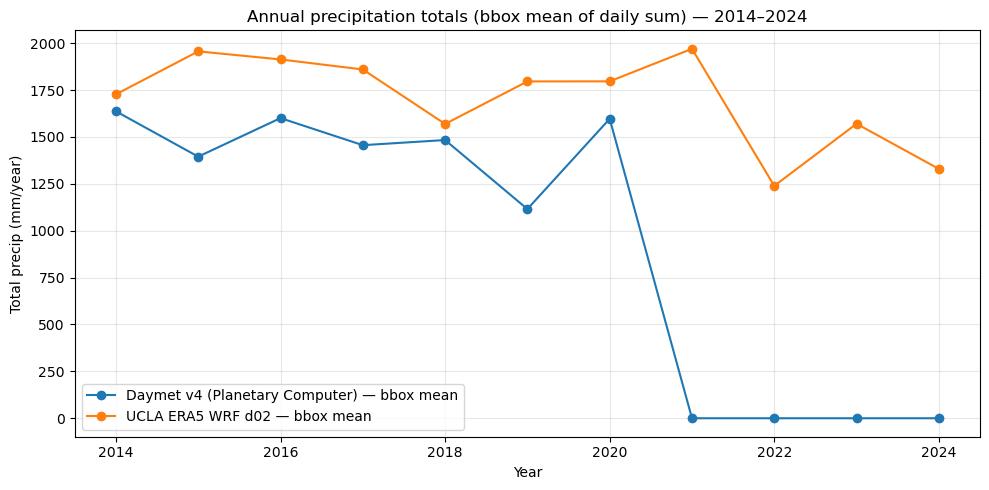


Daymet annual totals: {2014: 1636.8994140625, 2015: 1395.156982421875, 2016: 1600.706298828125, 2017: 1456.3355712890625, 2018: 1483.6739501953125, 2019: 1115.6192626953125, 2020: 1596.8565673828125, 2021: 0.0, 2022: 0.0, 2023: 0.0, 2024: 0.0}
UCLA annual totals: {2014: 1727.51025390625, 2015: 1956.6011962890625, 2016: 1913.598876953125, 2017: 1860.083251953125, 2018: 1569.46337890625, 2019: 1796.3226318359375, 2020: 1796.70654296875, 2021: 1970.2532958984375, 2022: 1239.1973876953125, 2023: 1570.500244140625, 2024: 1329.7177734375}


In [ ]:
import sys
from pathlib import Path
from urllib.parse import urlparse, urlunparse

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

OUTDIR = Path("/data0/balaji24/data/derived/daymet_pc_vs_ucla_annual_totals_resign")
OUTDIR.mkdir(parents=True, exist_ok=True)

BBOX = dict(north=49.8, south=48.0, west=-123.4, east=-120.2)
YEARS = list(range(2014, 2025))

# ---------------------------
# UCLA ERA5 d02 (downloaded NetCDFs) + static coord file (lat2d/lon2d)
# ---------------------------
UCLA_PREC_DIR = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# ---------------------------
# Ensure deps
# ---------------------------
def ensure_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr", "aiohttp"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem

# ---------------------------
# Daymet: SAS-aware filesystem
# ---------------------------
class SASAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

def get_daymet_mapper():
    """Re-sign Daymet Zarr root each time to avoid token expiry."""
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed = pc.sign(col.assets[asset_key]).href

    u = urlparse(signed)
    base = f"{u.scheme}://{u.netloc}{u.path}"
    query = u.query

    fs = SASAppendingHTTPFileSystem(query)
    mapper = fs.get_mapper(base)
    return mapper

# ---------------------------
# Daymet projection helper (Daymet LCC)
# ---------------------------
def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

def bbox_lonlat_to_xy_bounds(bbox):
    tfm = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)
    corners = [
        (bbox["west"],  bbox["south"]),
        (bbox["west"],  bbox["north"]),
        (bbox["east"],  bbox["south"]),
        (bbox["east"],  bbox["north"]),
    ]
    xs, ys = zip(*[tfm.transform(lon, lat) for lon, lat in corners])
    return float(min(xs)), float(max(xs)), float(min(ys)), float(max(ys))

def daymet_annual_total_for_year(year: int) -> float:
    """
    Re-sign -> open -> slice year+bbox -> compute annual total (bbox mean of daily sum) -> close
    This avoids SAS expiry mid-run.
    """
    mapper = get_daymet_mapper()
    ds = xr.open_zarr(mapper, consolidated=True)

    xmin, xmax, ymin, ymax = bbox_lonlat_to_xy_bounds(BBOX)
    y0 = float(ds["y"].values[0])
    y1 = float(ds["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds["prcp"].sel(
        time=slice(f"{year}-01-01", f"{year}-12-31"),
        x=slice(xmin, xmax),
        y=y_slice,
    ).chunk({"time": 365, "y": 512, "x": 512})

    spatial_dims = [d for d in pr.dims if d != "time"]
    tot = pr.sum(dim="time", skipna=True).mean(dim=spatial_dims, skipna=True)

    out = float(tot.compute().values)
    ds.close()
    return out

# ---------------------------
# UCLA: bbox-mean (memory-safe) using static coord mask
# ---------------------------
def pick_time_dim(da):
    if "day" in da.dims: return "day"
    if "time" in da.dims: return "time"
    for d in da.dims:
        if "day" in d.lower() or "time" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def build_ucla_bbox_mask(coord_file: Path, bbox: dict) -> xr.DataArray:
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True)
    lon = g["lon2d"].squeeze(drop=True)
    mask = ((lat >= bbox["south"]) & (lat <= bbox["north"]) &
            (lon >= bbox["west"])  & (lon <= bbox["east"])).astype("float32")
    print("[UCLA] mask count:", int(mask.sum().values), "out of", mask.size)
    g.close()
    return mask

UCLA_MASK = build_ucla_bbox_mask(UCLA_COORD_FILE, BBOX)

def bbox_mean_timeseries(pr: xr.DataArray, tdim: str, mask2d: xr.DataArray) -> xr.DataArray:
    spatial_dims = [d for d in pr.dims if d != tdim]

    # align mask dims by size if needed
    mask_aligned = mask2d
    if set(mask_aligned.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask_aligned.dims:
            for pd in spatial_dims:
                if mask_aligned.sizes[md] == pr.sizes[pd]:
                    rename_map[md] = pd
                    break
        mask_aligned = mask_aligned.rename(rename_map)

    denom = mask_aligned.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask_aligned).sum(dim=spatial_dims, skipna=True)
    return num / denom

def ucla_annual_total_for_year(year: int) -> float:
    f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=year)
    if not f.exists():
        return np.nan
    ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
    pr = ds["prec"]
    tdim = pick_time_dim(pr)
    ts = bbox_mean_timeseries(pr, tdim, UCLA_MASK)
    tot = float(ts.sum(dim=tdim, skipna=True).compute().values)
    ds.close()
    return tot

# ---------------------------
# Run annual totals
# ---------------------------
daymet_tot = {}
ucla_tot = {}

for yr in YEARS:
    print(f"[DAYMET] {yr}")
    try:
        daymet_tot[yr] = daymet_annual_total_for_year(yr)
    except Exception as e:
        print(f"  !! Daymet failed for {yr}: {type(e).__name__}: {e}")
        daymet_tot[yr] = np.nan

for yr in YEARS:
    print(f"[UCLA] {yr}")
    try:
        ucla_tot[yr] = ucla_annual_total_for_year(yr)
    except Exception as e:
        print(f"  !! UCLA failed for {yr}: {type(e).__name__}: {e}")
        ucla_tot[yr] = np.nan

# ---------------------------
# Plot annual totals
# ---------------------------
years = YEARS
daymet_vals = [daymet_tot.get(y, np.nan) for y in years]
ucla_vals   = [ucla_tot.get(y, np.nan) for y in years]

plt.figure(figsize=(10, 5))
plt.plot(years, daymet_vals, marker="o", label="Daymet v4 (Planetary Computer) — bbox mean")
plt.plot(years, ucla_vals,   marker="o", label="UCLA ERA5 WRF d02 — bbox mean")
plt.title("Annual precipitation totals (bbox mean of daily sum) — 2014–2024")
plt.xlabel("Year")
plt.ylabel("Total precip (mm/year)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

png = OUTDIR / "annual_total_prcp_daymet_vs_ucla_bboxmean_2014_2024.png"
plt.savefig(png, dpi=160)
print("Saved plot →", png)
plt.show()

print("\nDaymet annual totals:", daymet_tot)
print("UCLA annual totals:", ucla_tot)

[MASK] Upper Skagit: 61 cells inside (of 91800)
[MASK] Sauk: 22 cells inside (of 91800)
[MASK] Lower Skagit: 11 cells inside (of 91800)
[UCLA] DJF 2014 window 2013-12-01..2014-02-28
[UCLA] DJF 2015 window 2014-12-01..2015-02-28
[UCLA] DJF 2016 window 2015-12-01..2016-02-29
[UCLA] DJF 2017 window 2016-12-01..2017-02-28
[UCLA] DJF 2018 window 2017-12-01..2018-02-28
[UCLA] DJF 2019 window 2018-12-01..2019-02-28
[UCLA] DJF 2020 window 2019-12-01..2020-02-29
[UCLA] DJF 2021 window 2020-12-01..2021-02-28
[UCLA] DJF 2022 window 2021-12-01..2022-02-28
[UCLA] DJF 2023 window 2022-12-01..2023-02-28
[UCLA] DJF 2024 window 2023-12-01..2024-02-29
[UCLA] MAM 2014 window 2014-03-01..2014-05-31
[UCLA] MAM 2015 window 2015-03-01..2015-05-31
[UCLA] MAM 2016 window 2016-03-01..2016-05-31
[UCLA] MAM 2017 window 2017-03-01..2017-05-31
[UCLA] MAM 2018 window 2018-03-01..2018-05-31
[UCLA] MAM 2019 window 2019-03-01..2019-05-31
[UCLA] MAM 2020 window 2020-03-01..2020-05-31
[UCLA] MAM 2021 window 2021-03-01..2

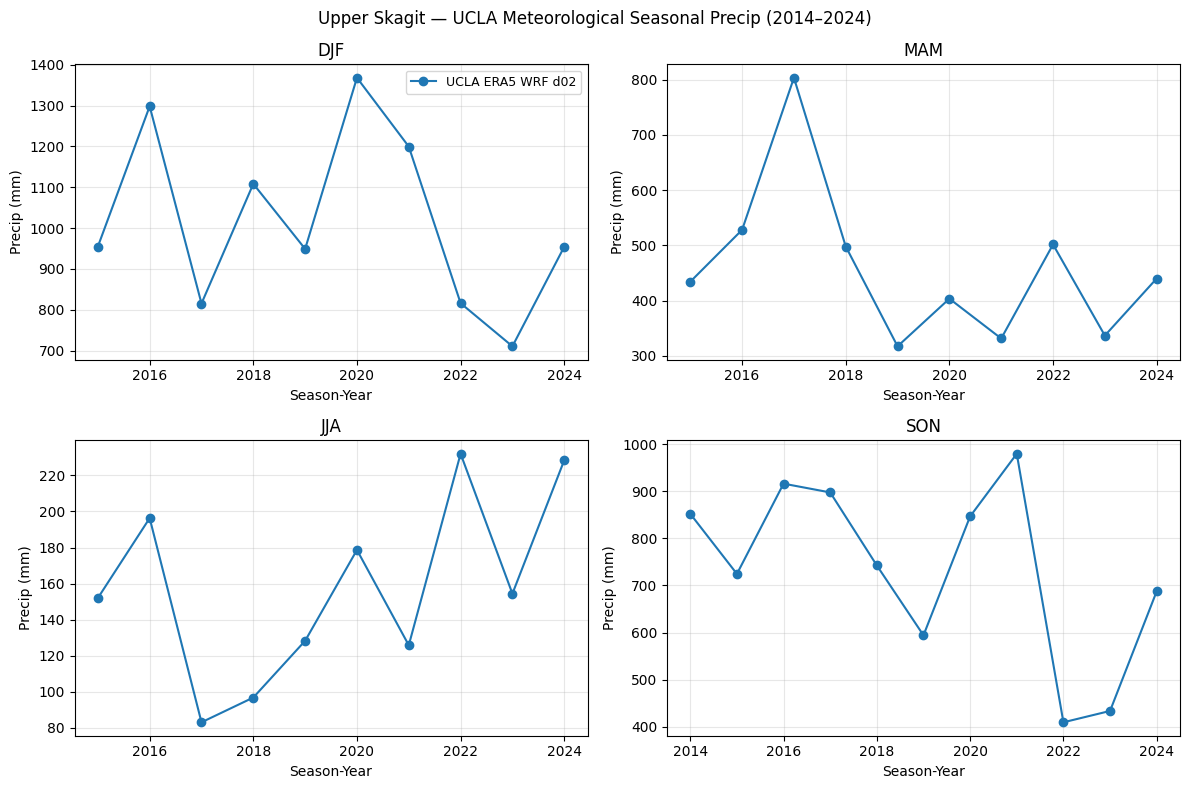

Saved plot → /data0/balaji24/data/derived/ucla_era5_like_code2_but_code1_varieties/ucla_met_season_Sauk_2014_2024.png


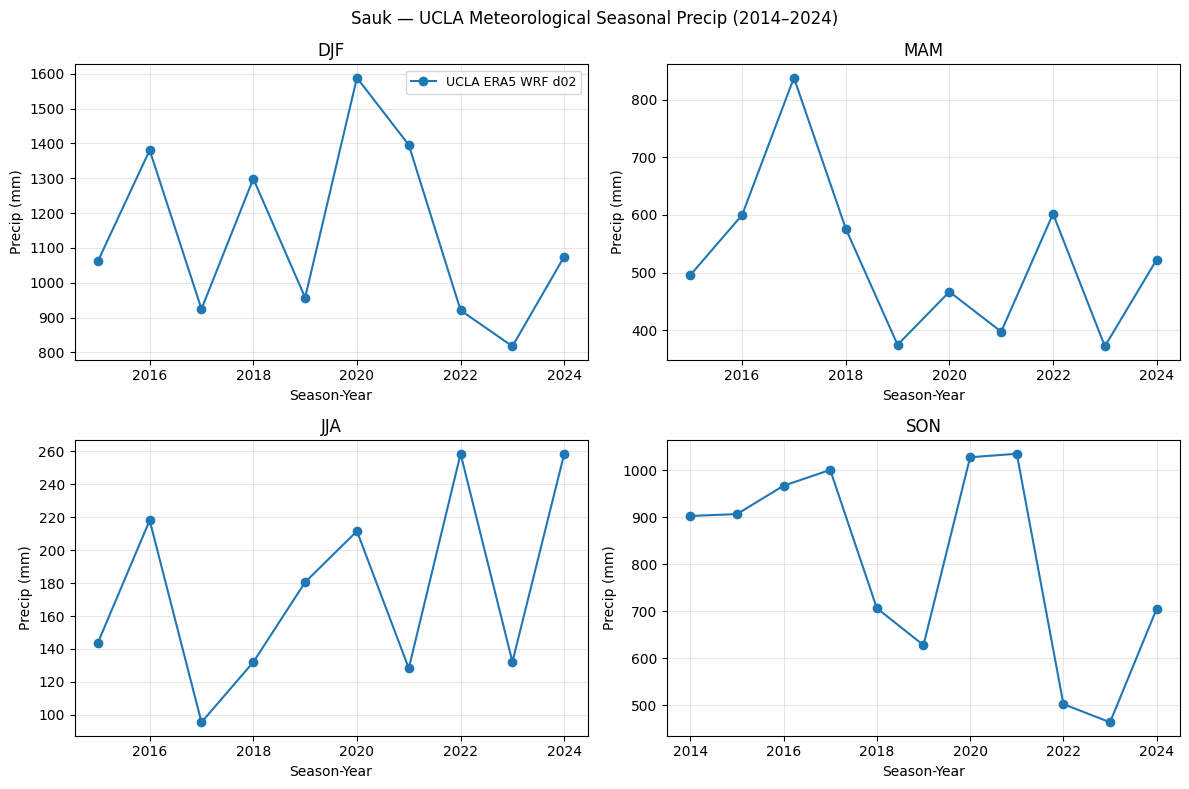

Saved plot → /data0/balaji24/data/derived/ucla_era5_like_code2_but_code1_varieties/ucla_met_season_Lower_Skagit_2014_2024.png


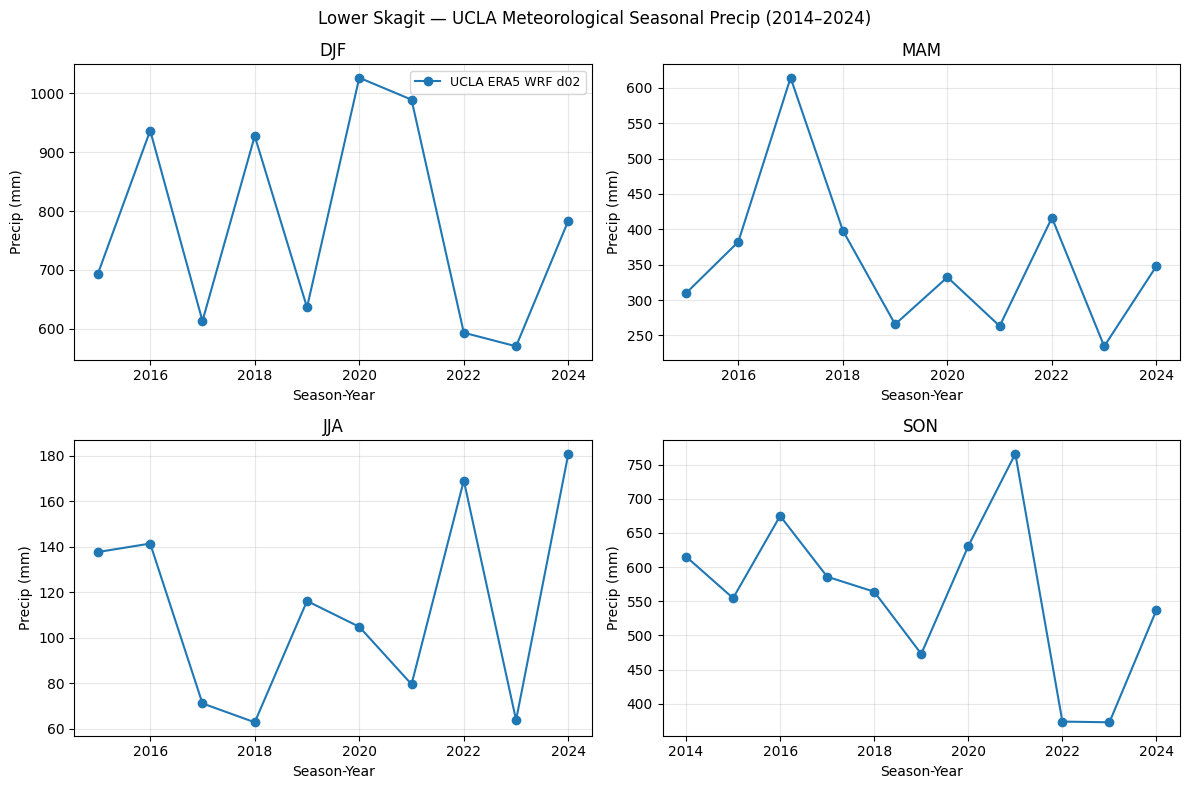

Saved summary plot → /data0/balaji24/data/derived/ucla_era5_like_code2_but_code1_varieties/ucla_summary_sum_seasons_2014_2024.png


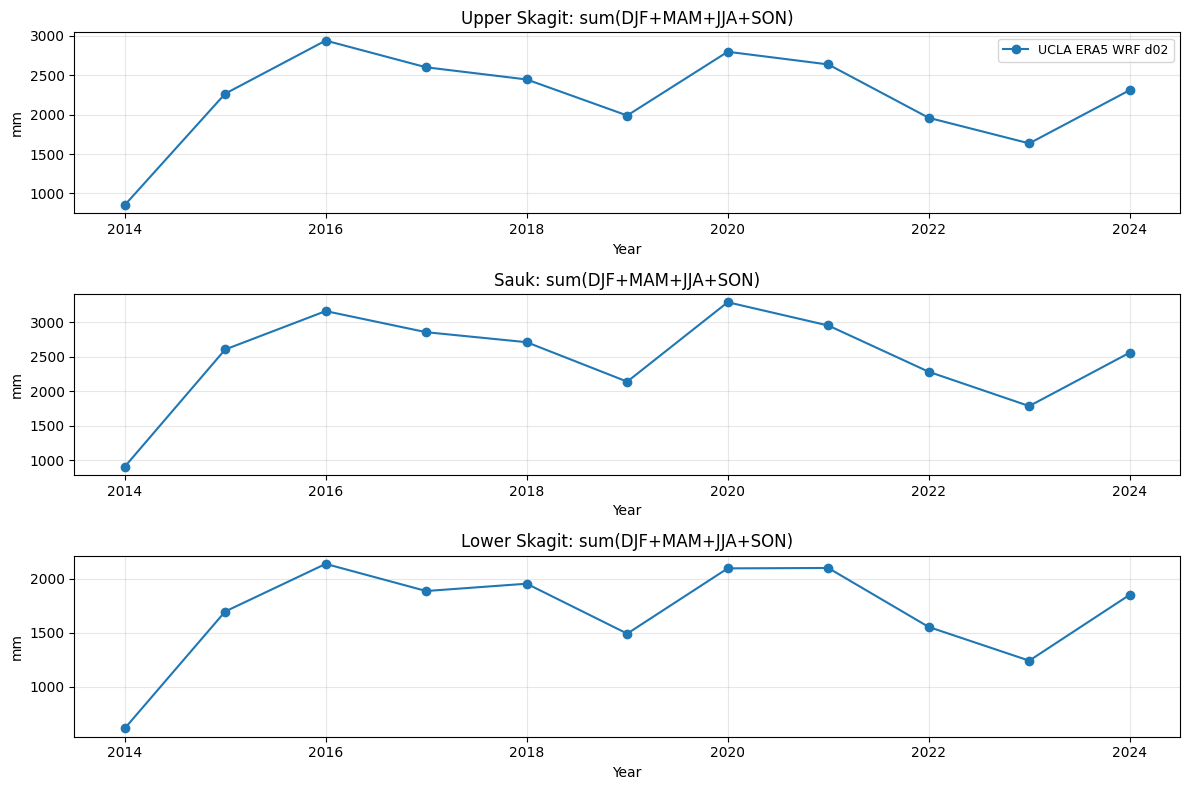

In [ ]:
"""

UCLA ERA5 WRF d02 (daily NetCDF, mask-based, memory-safe),

3 regions (Upper Skagit / Sauk / Lower Skagit) from HUC8 polygons (clipped to Skagit)
Meteorological seasons DJF/MAM/JJA/SON (DJF labeled by ending year)
Per-region plots with 4 seasonal panels
Combined summary plot: sum(DJF+MAM+JJA+SON) per year
“Hide zeros” in plots (0 to NaN for plotting only)

No regionmask dependency. Masks are built once on UCLA grid using lat2d/lon2d from wrfinput_d02_coord.nc.
"""

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------------------
# CONFIG
# ---------------------------
BASE = Path("/data0/balaji24/data")
OUT  = BASE / "derived" / "ucla_era5_like_code2_but_code1_varieties"
OUT.mkdir(parents=True, exist_ok=True)

BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

YEAR_MIN, YEAR_MAX = 2014, 2024  # season-year labels (DJF labeled by ending year)

UCLA_PREC_DIR       = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE  = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE     = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# Output files
CSV_OUT = OUT / f"ucla_met_season_totals_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
PNG_SUM = OUT / f"ucla_summary_sum_seasons_{YEAR_MIN}_{YEAR_MAX}.png"

# ---------------------------
# Helpers
# ---------------------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}
SEASONS_ORDER = ["DJF", "MAM", "JJA", "SON"]

def season_time_window(year, season_label):
    """Return ISO start/end strings for season-year."""
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def hide_zeros(y):
    y = np.asarray(y, dtype="float64")
    y[y == 0] = np.nan
    return y

# ---------------------------
# Load regions + clip to Skagit 
# ---------------------------
def load_regions_clipped():
    import geopandas as gpd
    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(f"No matching HUC8 regions found for {REGION_NAMES}. Check 'Name' field in {HUC8_GEO}.")

    clipped = gpd.overlay(huc8_3, skagit, how="intersection")
    clipped = clipped[["Name", "geometry"]].reset_index(drop=True)

    clipped["Name"] = pd.Categorical(clipped["Name"], categories=REGION_NAMES, ordered=True)
    clipped = clipped.sort_values("Name").reset_index(drop=True)
    return clipped

# ---------------------------
# Build region masks on UCLA grid
# ---------------------------
def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]

        # Fast path: shapely.contains_xy (Shapely >=2)
        try:
            from shapely import contains_xy
            m_flat = contains_xy(geom, lonv, latv)
        except Exception:
            # Fallback: prepared geometry loop (slower)
            from shapely.prepared import prep
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
        print(f"[MASK] {name}: {int(mask2d.sum())} cells inside (of {mask2d.size})")

    grid = xr.Dataset({"lat2d": lat, "lon2d": lon})
    return masks, grid

def masked_mean_timeseries(pr: xr.DataArray, tdim: str, mask2d: xr.DataArray) -> xr.DataArray:
    """Mean over a fixed 2D mask for each timestep: sum(pr*mask)/sum(mask)."""
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

# ---------------------------
# UCLA files are Sep(Y)..Aug(Y+1), not Jan..Dec
# ---------------------------
def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    # Sep..Dec belong to label=year; Jan..Aug belong to label=year-1
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    """
    Open the correct UCLA file(s) based on actual date coverage (Sep..Aug),
    concat, and slice [t0, t1].
    Returns (pr_da, parent_datasets_list). Caller must close all parents.
    """
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)

    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []

    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue

        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})

        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time")
    pr_all = pr_all.sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

# ---------------------------
# Main compute
# ---------------------------
regions_gdf = load_regions_clipped()
REGION_MASKS, _UCLA_GRID = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

rows = []

for season in SEASONS_ORDER:
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        t0, t1 = season_time_window(yr, season)
        print(f"[UCLA] {season} {yr} window {t0}..{t1}")

        pr, parents = open_ucla_prec_for_window(t0, t1)
        if pr is None:
            continue

        try:
            for rname in REGION_NAMES:
                mask = REGION_MASKS[rname]
                ts = masked_mean_timeseries(pr, "time", mask)
                tot = float(ts.sum(dim="time", skipna=True).compute().values)

                if np.isfinite(tot):
                    rows.append({
                        "dataset": "UCLA ERA5 WRF d02 (daily NetCDF)",
                        "region": rname,
                        "season": season,
                        "year": int(yr),
                        "mm": float(tot),
                    })
        finally:
            for ds in parents:
                try: ds.close()
                except Exception: pass

# ---------------------------
# Save + Plot
# ---------------------------
df = pd.DataFrame(rows).sort_values(["region", "season", "year"]).reset_index(drop=True)
print(df.head(30))

df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# Per-region seasonal plot (4 panels)
for region in REGION_NAMES:
    sub = df[df["region"] == region]
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, season in enumerate(SEASONS_ORDER, start=1):
        ax = plt.subplot(2, 2, i)
        ssub = sub[sub["season"] == season].sort_values("year")

        if ssub.empty:
            ax.set_title(f"{season} (no data)")
            ax.grid(True, alpha=0.3)
            continue

        ax.plot(
            ssub["year"].values,
            hide_zeros(ssub["mm"].values),
            marker="o",
            label="UCLA ERA5 WRF d02",
        )
        ax.set_title(season)
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Precip (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=9)

    fig.suptitle(f"{region} — UCLA Meteorological Seasonal Precip ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"ucla_met_season_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Summary: sum over seasons by year
summary = df.groupby(["region", "year"], as_index=False)["mm"].sum()

fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    s = summary[summary["region"] == region].sort_values("year")

    ax.plot(
        s["year"].values,
        hide_zeros(s["mm"].values),
        marker="o",
        label="UCLA ERA5 WRF d02",
    )
    ax.set_title(f"{region}: sum(DJF+MAM+JJA+SON)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(PNG_SUM, dpi=160)
print("Saved summary plot →", PNG_SUM)
plt.show()